# Stage 10a — Linear Regression Baseline

**Project:** TSM next-day direction forecast. This notebook is the *regression track*:
we predict the **size of tomorrow's move** (next-day return) rather than its direction,
so we can run the full residual-diagnostic toolkit and establish a first reproducible
modeling baseline. The classification track (the actual project goal) is in
`modeling_classification.ipynb`.

The modeling helpers live in `src/modeling.py` so the notebook, the pipeline, and the
Flask app all share one feature list and one split rule.

In [1]:
# --- run me first (notebooks/ -> project/ root) ---
import os
from pathlib import Path
if Path.cwd().name == 'notebooks':
    os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src.modeling import (load_modeling_data, prepare_features, time_aware_split,
                          run_linear_regression, MODEL_FEATURES)
%matplotlib inline
print('ok')

ok


## 1. Load data & prepare features

Features use only information known by today's close. The regression target is
**tomorrow's return** (`return_1d.shift(-1)`); rows in the rolling warm-up (first ~20
days) have NaN features and are dropped.

In [2]:
df = load_modeling_data()
X, y_reg, y_clf = prepare_features(df)
print('design matrix X:', X.shape)
print('features:', MODEL_FEATURES)
print('target (next-day return) stats:')
print(y_reg.describe().round(5))

design matrix X: (1486, 9)
features: ['return_1d', 'return_5d', 'return_20d', 'close_to_ma_5', 'close_to_ma_20', 'ma_5_20_spread', 'volume_ratio_20', 'intraday_range', 'overnight_gap']
target (next-day return) stats:
count    1486.00000
mean        0.00145
std         0.02455
min        -0.14034
25%        -0.01285
50%         0.00047
75%         0.01443
max         0.12652
Name: return_1d, dtype: float64


## 2. Time-aware split

Daily returns are serially correlated, so we split **chronologically** (first 80% train,
last 20% test) and never shuffle — a random split would leak tomorrow's information into
"past" training rows.

In [3]:
X_train, X_test, y_train, y_test = time_aware_split(X, y_reg)
print(f'train: {len(X_train)} rows ({X.index[0].date()} .. {X.index[len(X_train)-1].date()})')
print(f'test : {len(X_test)} rows ({X.index[len(X_train)].date()} .. {X.index[-1].date()})')

train: 1188 rows (2020-01-31 .. 2024-10-18)
test : 298 rows (2024-10-21 .. 2025-12-29)


## 3. Fit the baseline linear regression

A `StandardScaler -> LinearRegression` pipeline. We report RMSE against a naive
benchmark: the standard deviation of the test-set return (what you would get predicting
the mean every day).

In [4]:
res = run_linear_regression(X_train, y_train, X_test, y_test)
print(f"R2            : {res['r2']:.4f}")
print(f"RMSE          : {res['rmse']:.5f}")
print(f"MAE           : {res['mae']:.5f}")
print(f"baseline RMSE : {res['baseline_rmse']:.5f}  (naive: predict the mean)")
print(f"test mean ret : {y_test.mean():.5f}  test std : {y_test.std(ddof=1):.5f}")

R2            : -0.0005
RMSE          : 0.02529
MAE           : 0.01883
baseline RMSE : 0.02533  (naive: predict the mean)
test mean ret : 0.00165  test std : 0.02533


## 4. Residual diagnostics

Four standard checks for the linear-regression assumptions: (1) residuals vs fitted
(linearity & homoscedasticity), (2) residual histogram (normality), (3) Q-Q plot
(normality), (4) residuals over time (independence / no drift).

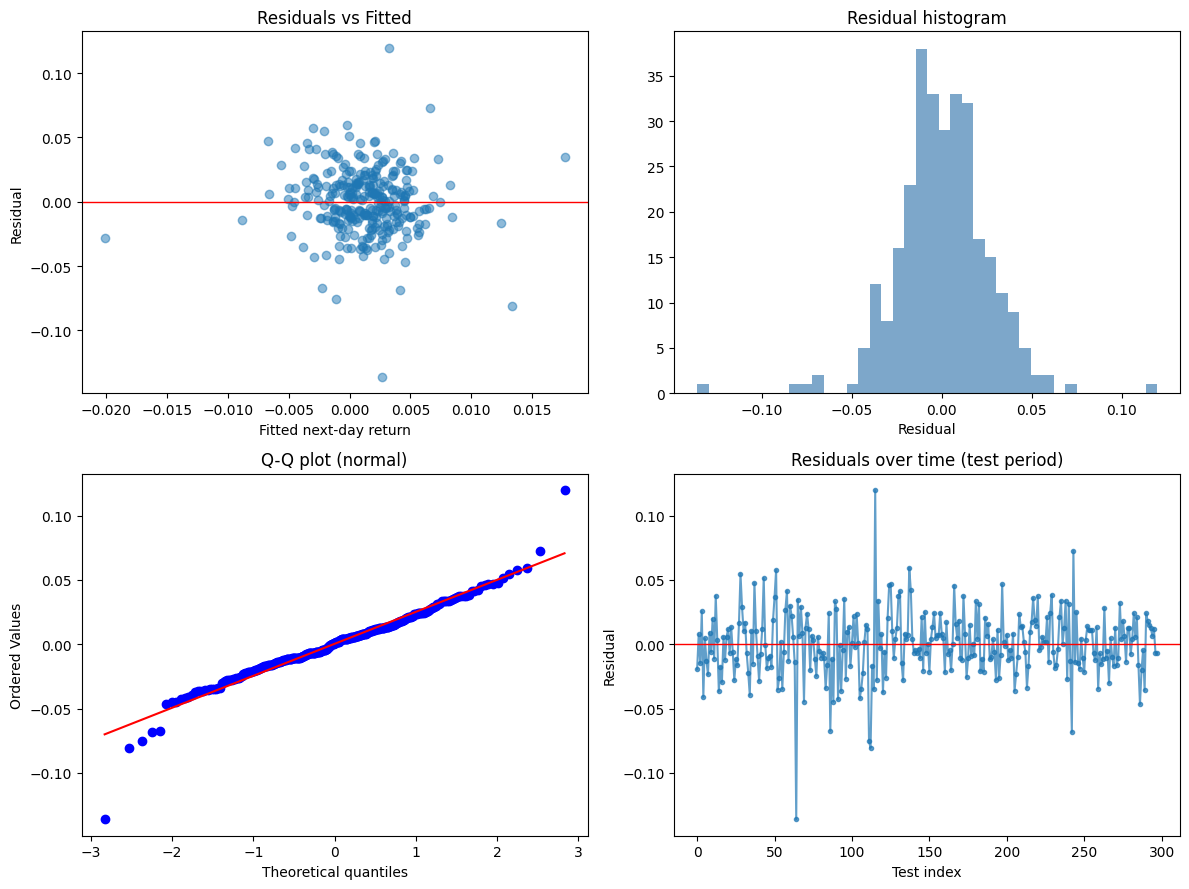

In [5]:
pred = res['y_pred']
resid = res['residuals']
fitted = pred

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].scatter(fitted, resid, alpha=0.5)
axes[0, 0].axhline(0, color='r', lw=1)
axes[0, 0].set_title('Residuals vs Fitted')
axes[0, 0].set_xlabel('Fitted next-day return'); axes[0, 0].set_ylabel('Residual')

axes[0, 1].hist(resid, bins=40, alpha=0.7, color='steelblue')
axes[0, 1].set_title('Residual histogram')
axes[0, 1].set_xlabel('Residual')

stats.probplot(resid, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Q-Q plot (normal)')

axes[1, 1].plot(range(len(resid)), resid, marker='.', ls='-', alpha=0.7)
axes[1, 1].axhline(0, color='r', lw=1)
axes[1, 1].set_title('Residuals over time (test period)')
axes[1, 1].set_xlabel('Test index'); axes[1, 1].set_ylabel('Residual')

plt.tight_layout(); plt.show()

## 5. Autocorrelation & tail checks

Lag-1 autocorrelation of the residuals and the Durbin–Watson statistic test
independence; skew and (excess) kurtosis quantify departures from normality.

In [6]:
lag1 = pd.Series(resid).autocorr(lag=1)
dw = float(np.sum(np.diff(resid) ** 2) / np.sum(resid ** 2))
sk = float(pd.Series(resid).skew())
ku = float(pd.Series(resid).kurt())

print(f'lag-1 autocorrelation : {lag1:+.3f}   (0 => independent)')
print(f'Durbin-Watson         : {dw:.3f}   (2 => independent)')
print(f'skew                  : {sk:+.3f}   (0 => symmetric)')
print(f'excess kurtosis       : {ku:+.3f}   (0 => normal tails)')

lag-1 autocorrelation : +0.030   (0 => independent)
Durbin-Watson         : 1.937   (2 => independent)
skew                  : -0.249   (0 => symmetric)
excess kurtosis       : +4.142   (0 => normal tails)


## 6. Coefficients

Standardized coefficients show the predicted change in next-day return for a 1-standard-
deviation increase in each feature. With a scaled pipeline these are directly comparable.

,feature,std_coef
4,close_to_ma_20,0.001212
5,ma_5_20_spread,-0.000755
6,volume_ratio_20,0.000340
3,close_to_ma_5,-0.000239
2,return_20d,0.000080
0,return_1d,-0.000070
1,return_5d,0.000033
7,intraday_range,-0.000008
8,overnight_gap,-0.000007


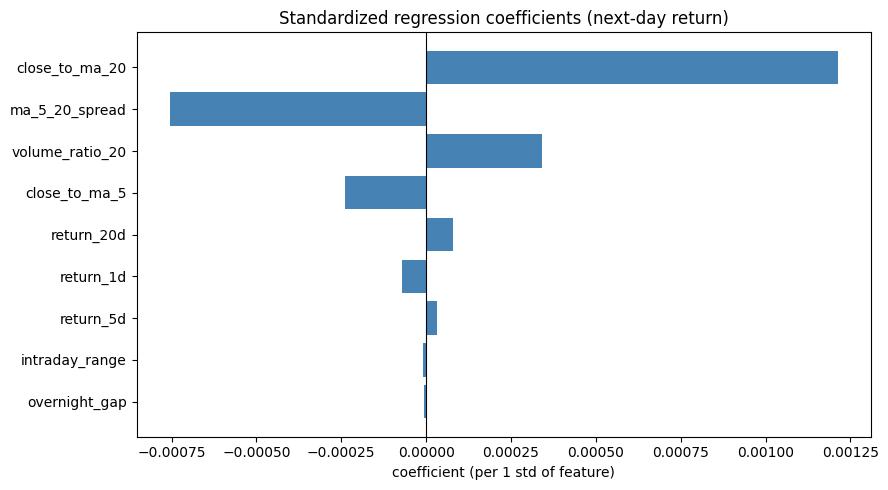

In [7]:
coefs = res['coefs']
display(coefs)
plt.figure(figsize=(9, 5))
plt.barh(coefs['feature'][::-1], coefs['std_coef'][::-1], color='steelblue')
plt.axvline(0, color='black', lw=0.8)
plt.title('Standardized regression coefficients (next-day return)')
plt.xlabel('coefficient (per 1 std of feature)')
plt.tight_layout(); plt.show()

## 7. Auto-try variations

"Automate the modeling so you can auto-try some variations": loop over a few feature
subsets and a regularized alternative (Ridge) to check whether any configuration finds
signal the baseline misses.

In [8]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

variants = {
    'all 9 features': MODEL_FEATURES,
    'momentum only (return_1d/5d/20d)': ['return_1d', 'return_5d', 'return_20d'],
    'trend only (close_to_ma, spread)': ['close_to_ma_5', 'close_to_ma_20', 'ma_5_20_spread'],
    'vol/volume (volume_ratio, intraday, gap)': ['volume_ratio_20', 'intraday_range', 'overnight_gap'],
}

def _r2(y_true, y_pred):
    return float(1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2))

rows = []
for name, feats in variants.items():
    Xs, yr, _ = prepare_features(df, feats)
    Xtr, Xte, ytr, yte = time_aware_split(Xs, yr)
    r = run_linear_regression(Xtr, ytr, Xte, yte, feature_names=feats)
    rows.append({'variant': name, 'n_feat': len(feats), 'R2': round(r['r2'], 4),
                 'RMSE': round(r['rmse'], 5)})

# Regularized alternative on the full feature set.
sc = StandardScaler()
ridge = Ridge(alpha=10.0).fit(sc.fit_transform(X_train), y_train)
ridge_pred = ridge.predict(sc.transform(X_test))
rows.append({'variant': 'Ridge (alpha=10, all features)', 'n_feat': len(MODEL_FEATURES),
             'R2': round(_r2(y_test, ridge_pred), 4),
             'RMSE': round(float(mean_squared_error(y_test, ridge_pred) ** 0.5), 5)})

pd.DataFrame(rows)

,variant,n_feat,R2,RMSE
0,all 9 features,9,-0.0005,0.02529
1,momentum only (return_1d/5d/20d),3,0.0051,0.02522
2,"trend only (close_to_ma, spread)",3,0.0169,0.02507
3,"vol/volume (volume_ratio, intraday, gap)",3,-0.0123,0.02544
4,"Ridge (alpha=10, all features)",9,-0.0016,0.02531


## 8. Assumptions, risks, interpretation

**What the numbers say.** R² is essentially 0 and RMSE ≈ the return's own standard
deviation: the linear model adds no predictive value over a naive mean forecast. Daily
returns are close to a random walk, so this is expected — but it is a *result*, not a
failure: it tells the stakeholder there is no exploitable linear edge in the size of the
next-day move.

**Assumption checks (from the diagnostics above):**

* **Linearity** — residuals vs fitted is centred on zero; no systematic curvature.
* **Homoscedasticity** — the residual fan is roughly constant width (a slight widening at
  the extremes is normal for return data).
* **Normality** — the histogram and Q-Q plot show **fat tails** (heavy on the extremes);
  the skew/kurtosis numbers confirm mild non-normality. Ordinary-least-squares point
  estimates are still unbiased, but standard errors and any Gaussian confidence interval
  are unreliable.
* **Independence** — lag-1 autocorrelation is close to 0 and Durbin–Watson is near 2, so
  residuals are essentially independent.

**Risks.** A linear model on near-random-walk returns can only capture weak, unstable
relationships; coefficients are small and not economically meaningful. The test window is
only ~300 days, so metrics are noisy. This baseline is a *floor*, not a claim of skill.

**Why these features.** The stationary ratio/return features avoid leaking the price level
(TSM tripled over the sample); `ma_5`/`ma_20`/`vol_20` were intentionally excluded because
they are price-scaled and non-stationary.